## Project: Identify cars or trucks
### Vehicle Classification Using Transfer Learning (VGG16)

This project implements a transfer learning approach based on the VGG16 convolutional neural network to perform an image classification task: distinguishing between cars and trucks.

Although the classification problem is relatively simple, the project focuses on key deep learning concepts, including:
- Transfer learning with pre-trained CNN models
- Building and training TensorFlow/Keras models
- Using sequential architectures
- Reusing feature extraction blocks from established CNN architectures

The project introduces applying state-of-the-art computer vision techniques to a binary classification problem.

#### 1. Import project libraries and setting matplotlib defaults

In [101]:
# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

In [3]:
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells

#### 2. Define a function for reproducibility

In [5]:
# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed(31415)

#### 3. Load datasets


In [35]:
#Check current directory
import os
print(os.getcwd())

C:\Users\juan-david\Documents\JuanDavidBriceno\Administrative documents\HSE - Advanced Machine Learning Specialization\Understanding real life projects\Project-Identify_cars_or_trucks


In [37]:
# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    './train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)

Found 5117 files belonging to 2 classes.


In [39]:
ds_valid_ = image_dataset_from_directory(
    './validation',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

Found 5051 files belonging to 2 classes.


#### 4. Define functions for processing images to floating vectors

In [41]:
# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

#### 5. Create transformation pipelines (chains of steps that transforms data)

In this case the pipeline does:

-Apply a function to every pixel in the images to normalise values in float32.

-Stores processed data in memory to avoid recomputing.

-Loads next batch while model is training.

In [43]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [45]:
ds_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Properties of these tf.data.Dataset objects:

-They are lazy so data is not loaded all at once and computed only when needed.

-They are iterable but not indexable so: ds_train[0] is not correct.

-Produces data in chunks (batches) like (64 images, 64 labels) per step.

AUTOTUNE is for telling tensorflow to automatically decide the best number of parallel operations and buffering for data loading.

#### 6. Explore some images values in these tf pipelines by iterating


In [47]:
#See structure
images, labels = next(iter(ds_train))
print(images.shape)
print(labels.shape)

(64, 128, 128, 3)
(64, 1)


In [49]:
#CHeck values
print(images.dtype)
print(labels.dtype)
print(images[0])
print(labels[0])

<dtype: 'float32'>
<dtype: 'float32'>
tf.Tensor(
[[[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.00392157 0.        ]
  [0.         0.00392157 0.        ]
  [0.         0.00392157 0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.00392157 0.        ]
  [0.         0.00392157 0.        ]
  [0.         0.00392157 0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.00392157 0.        ]
  [0.         0.00392157 0.        ]
  [0.         0.00392157 0.        ]]

 ...

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  ...
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         

The way print(images[0]) shows the values of the pixels is like this :

[

  [pixel, pixel, pixel, ..., pixel],   # row 0
  
  [pixel, pixel, pixel, ..., pixel],   # row 1
  
  ...
  
  [pixel, pixel, pixel, ..., pixel]    # row 128
  
]

It means that the representation is like: tf.Tensor([row1, row2, row3...row128]); each row has 128 pixels, and each pixel has [R,G,B].

#### 7. Depict some images from these create tf pipelines

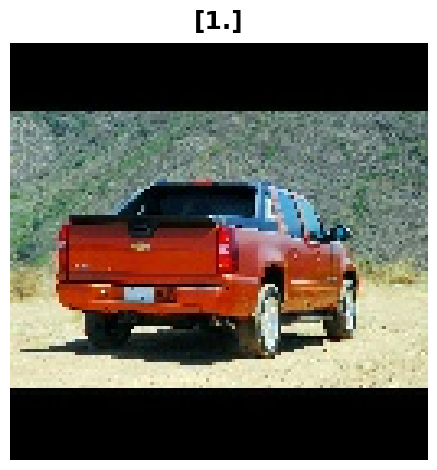

In [53]:
for images, labels in ds_train.take(1):
    plt.imshow(images[0])
    plt.title(labels[0].numpy())
    plt.axis("off")
    plt.show()

#### 8. Load pretrained base model for transfert learning:

The most commonly used dataset for pretraining is ImageNet, a large dataset of many kind of natural images. Keras includes a variety models pretrained on ImageNet in its applications module. The pretrained model we use in this project is called VGG16.

In [73]:
#
pretrained_base = tf.keras.models.load_model(
    './cv-models/vgg16-pretrained-base',
)
pretrained_base.trainable = False

#### 9. Create a sequential model for adding the layers that classify data into car or trucks.

-The layer pretrained_base is the pretrained VGG16, which was trained with ImageNet data and extracts high-level features from edges, shapes, textures, object parts.

-A Flatten layer: Converts multi-dimensional features into a 1D vector.

-A Dense layer (hidden layer): Learns patterns from features, 6 neurons = 6 learned “concept detectors”, from our training set of images about cars and trucks.

-An Output layer: Produces final prediction. It Ooutputs numbers between 0 and 1Interpreted as probability.

Note: Freezing the pretrained VGG16 (`pretrained_base.trainable = False`) prevents its weights from being updated during training, so it acts as a fixed feature extractor using learned ImageNet features. If set to `True`, the pretrained layers are also fine-tuned on the new dataset, which can improve performance if the dataset is large and similar, but may also lead to overfitting or loss of general features if the dataset is small or very different.

In [113]:
model = keras.Sequential([
    pretrained_base,
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

The following diagram explain the architecture case (model):

🖼️ Image (128×128×3)

        ↓
🧠 VGG16 (feature extraction):the base net of this project

        ↓
📦 Feature map (4×4×512) this is the shape of outputs given by the base net, or the extracted features (It transforms the image into some learned visual features). After passing through the base net convolutional and pooling layers, the image height and width are reduced in spatial dimensions: 128 → 64 → 32 → 16 → 8 → 4 (five pooling layers divide dimensions by 2 each time). 512 refers to the amount of filters in the VGG16.

        ↓ At this point, the model has understood the image, but the information is still arranged like a small cube.
🔄 Flatten (8192 vector). The next part of the model (Dense layers) cannot work directly with multi-dimensional data like cubes or grids. It expects a simple list of numbers (a vector). For this reason, we use a Flatten layer (or a similar operation) to convert the feature maps into a 1D vector that the Dense layers can process.
        ↓
🧠 Dense (6, ReLU)

        ↓
🎯 Dense (1, Sigmoid)

        ↓
📊 Prediction (Car / Truck)

#### 10. Training the model

In [64]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=3, #Reduced to 3 from 30 to train faster.
    verbose=1,
)

Epoch 1/3
80/80 [==============================] - 701s 9s/step - loss: 0.4565 - binary_accuracy: 0.8022 - val_loss: 0.4309 - val_binary_accuracy: 0.8018
Epoch 2/3
80/80 [==============================] - 703s 9s/step - loss: 0.3810 - binary_accuracy: 0.8425 - val_loss: 0.3999 - val_binary_accuracy: 0.8175
Epoch 3/3
80/80 [==============================] - 634s 8s/step - loss: 0.3426 - binary_accuracy: 0.8593 - val_loss: 0.3804 - val_binary_accuracy: 0.8325


#### 11. Plot curves for trainig-validation accuracy metrics
   
When training a neural network, it's always a good idea to examine the loss and metric plots. The history object contains this information in a dictionary history.history. We can use Pandas to convert this dictionary to a dataframe and plot it with a built-in method.

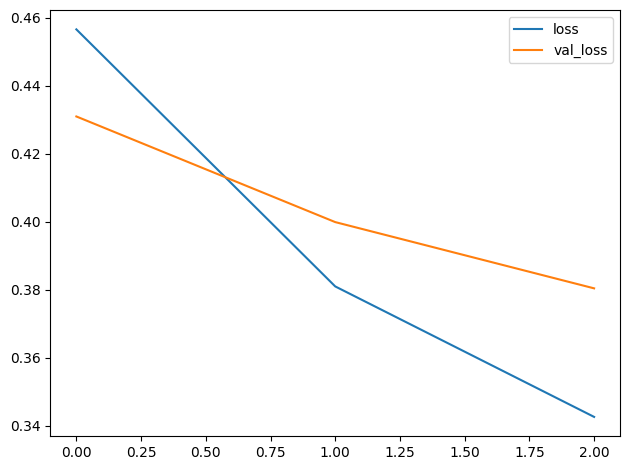

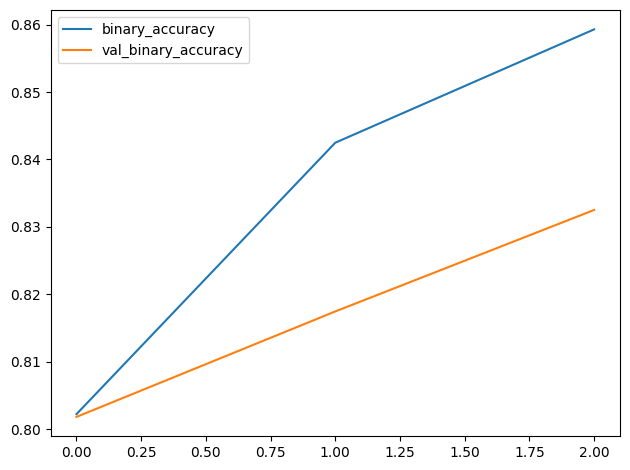

In [104]:
#Depict curves
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

## Conclusion

In this project, we exposed the structure of a CNN for image classification: the developed model consists of a "head" that acts as a classifier (the part of the model we trained for our specific task) placed on top of a base model (the VGG16 network), which performs feature extraction, providing transfer learning from the ImageNet scientific dataset (different from the one we use) to ours.

The head is essentially an ordinary classifier. For features, it uses those extracted by the base model. This is the basic idea behind convolutional classifiers: that we can attach a unit that performs feature extraction to the classifier itself.

This is one of the big advantages deep neural networks have over traditional machine learning models: given the right network structure, the deep neural network can learn how to engineer the features it needs to solve its problem.

In a next project, we'll take a look at how a convolutional base model accomplishes feature extraction (convolutions).